In [1]:
import math
import random
from typing import Dict, List, Tuple
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from src.custom_fastkan import FastKAN

# SciPy provides a reference implementation of spherical harmonics.
try:
    from scipy.special import sph_harm  # sph_harm(m, n, theta, phi) -> complex
except ImportError as e:
    raise ImportError(
        "SciPy is required for sph_harm(). Install with: pip install scipy"
    ) from e

device = "cpu"
print(f"Using device: {device}")
torch.set_default_dtype(torch.float32)

def set_seed(seed: int = 42) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

Using device: cpu


In [2]:
# Spherical harmonics dataset (2D): y = Re(Y_n^m(theta, phi)) with fixed (m,n)
M_ORDER = 1
N_DEGREE = 1  # choose one of the provided rows: (m=1,n=1)

def true_function_sph_harm(x: torch.Tensor, *, m: int = M_ORDER, n: int = N_DEGREE) -> torch.Tensor:
    """x has shape (N, 2) where x[:,0]=theta_scaled, x[:,1]=phi_scaled in [-1,1].
    Internally rescales to theta in [0, 2pi] and phi in [0, pi].
    Returns the REAL part (scalar regression target)."""
    theta_scaled = x[:, 0].detach().cpu().numpy()
    phi_scaled = x[:, 1].detach().cpu().numpy()
    theta = (theta_scaled + 1.0) * math.pi  # [-1,1] -> [0, 2pi]
    phi = (phi_scaled + 1.0) * (math.pi / 2.0)  # [-1,1] -> [0, pi]
    y_complex = sph_harm(m, n, theta, phi)
    y = np.real(y_complex).astype(np.float64)
    return torch.from_numpy(y).to(x.device, dtype=torch.float32)

num_samples = 20000
X = torch.rand(num_samples, 2) * 2 - 1  # (N,2) in [-1,1]
y = true_function_sph_harm(X)

# Filter any rare non-finite values
finite_mask = torch.isfinite(y)
X = X[finite_mask]
y = y[finite_mask]
num_samples = X.shape[0]

# Normalize target for easier optimization (metrics will be reported in original scale)
y_mean = y.mean()
y_std = y.std().clamp_min(1e-8)
y_norm = (y - y_mean) / y_std

# Train/val/test split
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size
X_train, X_val, X_test = torch.split(X, [train_size, val_size, test_size])
y_train, y_val, y_test = torch.split(y_norm, [train_size, val_size, test_size])

X_train, y_train = X_train.to(device), y_train.to(device)
X_val, y_val = X_val.to(device), y_val.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

print(f"Dataset: sph_harm(m={M_ORDER}, n={N_DEGREE}, theta, phi) -> Re")
print(f"Samples: {num_samples}")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Target normalization: mean={y_mean.item():.4e}, std={y_std.item():.4e}")

Dataset: sph_harm(m=1, n=1, theta, phi) -> Re
Samples: 20000
Train: torch.Size([14000, 2]), Val: torch.Size([3000, 2]), Test: torch.Size([3000, 2])
Target normalization: mean=-1.1719e-03, std=1.7207e-01


In [3]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

def denorm(y_hat_norm: torch.Tensor) -> torch.Tensor:
    return y_hat_norm * y_std.to(y_hat_norm.device) + y_mean.to(y_hat_norm.device)

def eval_mse_r2(model: torch.nn.Module, loader: DataLoader) -> Tuple[float, float]:
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            yhat = model(xb).squeeze(-1)
            preds.append(denorm(yhat).detach().cpu())
            targets.append(denorm(yb).detach().cpu())
    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    return float(mean_squared_error(targets, preds)), float(r2_score(targets, preds))

def train_regression(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    lr: float = 1e-3,
    max_epochs: int = 2000,
    patience: int = 200,
    verbose: bool = False,
    log_every: int = 100,
    min_delta: float = 1e-10,
    ) -> Dict[str, object]:
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    best_val = float("inf")
    best_state = None
    bad_epochs = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_n = 0
        for xb, yb in train_loader:
            optimizer.zero_grad(set_to_none=True)
            yhat = model(xb).squeeze(-1)
            loss = loss_fn(yhat, yb)
            loss.backward()
            optimizer.step()
            train_loss_sum += float(loss.item()) * xb.shape[0]
            train_n += xb.shape[0]
        train_mse_norm = train_loss_sum / max(train_n, 1)

        model.eval()
        val_loss_sum = 0.0
        val_n = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                yhat = model(xb).squeeze(-1)
                loss = loss_fn(yhat, yb)
                val_loss_sum += float(loss.item()) * xb.shape[0]
                val_n += xb.shape[0]
        val_mse_norm = val_loss_sum / max(val_n, 1)

        if val_mse_norm < best_val - min_delta:
            best_val = val_mse_norm
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if verbose and (epoch == 1 or epoch % log_every == 0):
            test_mse, test_r2 = eval_mse_r2(model, test_loader)
            print(
                f"Epoch {epoch:4d} | train(norm MSE)={train_mse_norm:.4e} "
                f"val(norm MSE)={val_mse_norm:.4e} | test(MSE)={test_mse:.4e} r2={test_r2:.4f}"
            )
        history.append((epoch, train_mse_norm, val_mse_norm))

        if bad_epochs >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    final_test_mse, final_test_r2 = eval_mse_r2(model, test_loader)
    return {
        "best_val_mse_norm": best_val,
        "final_test_mse": final_test_mse,
        "final_test_r2": final_test_r2,
        "epochs_ran": epoch,
        "history": history,
    }

In [4]:
def build_mlp(depth: int, width: int, input_dim: int = 2, output_dim: int = 1) -> nn.Module:
    assert depth >= 2
    layers: List[nn.Module] = []
    layers.append(nn.Linear(input_dim, width))
    layers.append(nn.ReLU())
    for _ in range(depth - 2):
        layers.append(nn.Linear(width, width))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(width, output_dim))
    return nn.Sequential(*layers)


def build_kan(*, layers_hidden: List[int]) -> FastKAN:
    # layers_hidden example: [2, 3, 2, 1]
    return FastKAN(
        layers_hidden,
        grid_min=-1,
        grid_max=1,
        num_grids=10,
        use_base_update=False,
        use_layernorm=False,
    )

# Fixed configs (single run) pulled from your table row: sph_harm(m=1,n=1)
KAN_LAYERS_HIDDEN = [2, 3, 2, 1]
MLP_DEPTH = 2
MLP_WIDTH = 500  # [2,500,1]

print("Fixed configs (no sweeps):")
print(f"  KAN: layers_hidden={KAN_LAYERS_HIDDEN}")
print(f"  MLP: depth={MLP_DEPTH}, width={MLP_WIDTH}")

Fixed configs (no sweeps):
  KAN: layers_hidden=[2, 3, 2, 1]
  MLP: depth=2, width=500


In [5]:
# Train a single KAN config (no sweep)
set_seed(42)
model = build_kan(layers_hidden=KAN_LAYERS_HIDDEN).to(device)
metrics = train_regression(model, train_loader, val_loader, lr=1e-3, max_epochs=100, patience=200, verbose=False)

best_kan = {
    "layers_hidden": KAN_LAYERS_HIDDEN,
    "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
    **metrics,
}

In [6]:
# Train a single MLP config (no sweep)
set_seed(42)
model = build_mlp(depth=MLP_DEPTH, width=MLP_WIDTH).to(device)
metrics = train_regression(model, train_loader, val_loader, lr=1e-3, max_epochs=200, patience=250, verbose=False)

best_mlp = {
    "depth": MLP_DEPTH,
    "width": MLP_WIDTH,
    "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
    **metrics,
}

In [7]:
# Compare the trained single-run models on test set
best_kan_model = build_kan(layers_hidden=best_kan["layers_hidden"]).to(device)
best_kan_model.load_state_dict(best_kan["state_dict"])

best_mlp_model = build_mlp(depth=best_mlp["depth"], width=best_mlp["width"]).to(device)
best_mlp_model.load_state_dict(best_mlp["state_dict"])

kan_test_mse, kan_test_r2 = eval_mse_r2(best_kan_model, test_loader)
mlp_test_mse, mlp_test_r2 = eval_mse_r2(best_mlp_model, test_loader)

# Derive depth/width fields from the configs (so the table has no NaNs)
kan_layers = list(best_kan["layers_hidden"])
kan_depth = len(kan_layers) - 1  # number of transitions between layer widths
kan_width = int(max(kan_layers[1:-1])) if len(kan_layers) > 2 else int(kan_layers[-1])

mlp_layers = [2, int(best_mlp["width"]), 1] if int(best_mlp["depth"]) == 2 else None

summary = pd.DataFrame([
    {
        "model": "KAN",
        "layers_hidden": str(kan_layers),
        "depth": int(kan_depth),
        "width": int(kan_width),
        "test_mse": float(kan_test_mse),
        "test_r2": float(kan_test_r2),
    },
    {
        "model": "MLP",
        "layers_hidden": str(mlp_layers) if mlp_layers is not None else "-",
        "depth": int(best_mlp["depth"]),
        "width": int(best_mlp["width"]),
        "test_mse": float(mlp_test_mse),
        "test_r2": float(mlp_test_r2),
    },
]).sort_values("test_mse")

display(summary)
ratio = (summary.loc[summary["model"] == "MLP", "test_mse"].values[0] / summary.loc[summary["model"] == "KAN", "test_mse"].values[0])
print(f"MLP/KAN test MSE ratio: {ratio:.3f}")

,model,layers_hidden,depth,width,test_mse,test_r2
0,KAN,"[2, 3, 2, 1]",3,3,1.825474e-07,0.999994
1,MLP,"[2, 500, 1]",2,500,2.661584e-07,0.999991


MLP/KAN test MSE ratio: 1.458


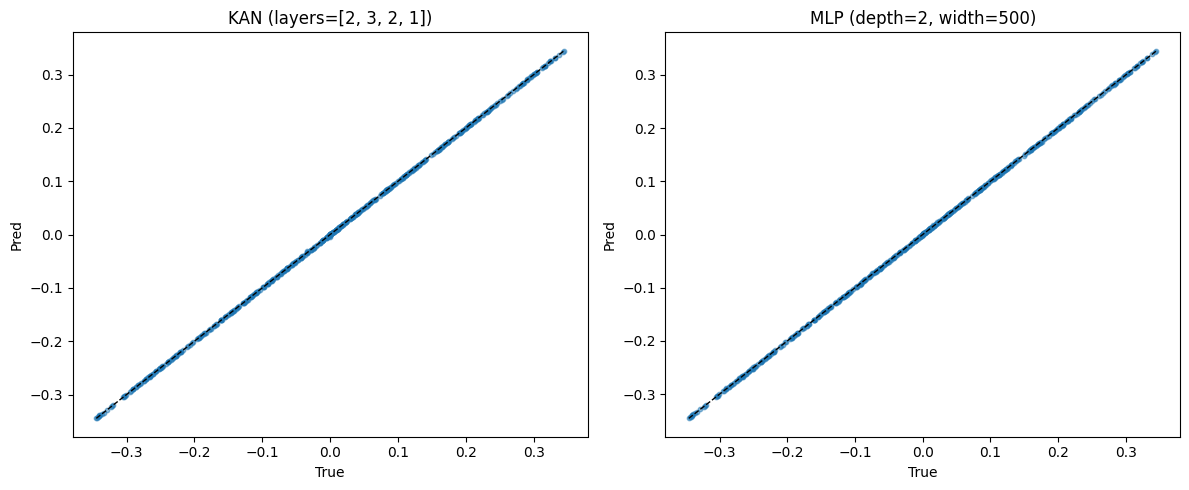

In [8]:
# Visual sanity-check: predicted vs true on a random subset of test points
best_kan_model.eval()
best_mlp_model.eval()

idx = torch.randperm(X_test.shape[0], device=device)[:500]
xb = X_test[idx]
yb_true = denorm(y_test[idx]).detach().cpu().numpy()

with torch.no_grad():
    yb_kan = denorm(best_kan_model(xb).squeeze(-1)).detach().cpu().numpy()
    yb_mlp = denorm(best_mlp_model(xb).squeeze(-1)).detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, yhat, title in [
    (axes[0], yb_kan, f"KAN (layers={best_kan['layers_hidden']})"),
    (axes[1], yb_mlp, f"MLP (depth={best_mlp['depth']}, width={best_mlp['width']})"),
 ]:
    ax.scatter(yb_true, yhat, s=10, alpha=0.5)
    mn = float(np.min([yb_true.min(), yhat.min()]))
    mx = float(np.max([yb_true.max(), yhat.max()]))
    ax.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Pred")
plt.tight_layout()
plt.show()

In [9]:
print("\nSummary (single-run):")
print(f"KAN: layers_hidden={best_kan['layers_hidden']}, test_mse={best_kan['final_test_mse']:.6e}, test_r2={best_kan['final_test_r2']:.6f}")
print(f"MLP: depth={best_mlp['depth']}, width={best_mlp['width']}, test_mse={best_mlp['final_test_mse']:.6e}, test_r2={best_mlp['final_test_r2']:.6f}")


Summary (single-run):
KAN: layers_hidden=[2, 3, 2, 1], test_mse=1.825474e-07, test_r2=0.999994
MLP: depth=2, width=500, test_mse=2.661584e-07, test_r2=0.999991


In [10]:
mlp_save_path = "model_pkls/funcsphharm_mlp_model.pkl"

mlp_hidden_dims = [best_mlp["width"]] * (best_mlp["depth"] - 1)

torch.save({
    "model_state_dict": best_mlp["state_dict"],
    "config": {
        "input_dim": 2,
        "hidden_dims": mlp_hidden_dims,
        "output_dim": 1,
        "target": {"name": "sph_harm_re", "m": M_ORDER, "n": N_DEGREE},
        "target_norm": {"mean": float(y_mean.item()), "std": float(y_std.item())},
    },
}, mlp_save_path)

print(f"MLP Model saved to {mlp_save_path}")

MLP Model saved to model_pkls/funcsphharm_mlp_model.pkl


In [11]:
kan_save_path = "model_pkls/funcsphharm_kan_model.pkl"

layers_hidden = best_kan["layers_hidden"]

torch.save({
    "model_state_dict": best_kan["state_dict"],
    "config": {
        "layers_hidden": layers_hidden,
        "grid_min": -1,
        "grid_max": 1,
        "num_grids": 10,
        "use_base_update": False,
        "use_layernorm": False,
        "target": {"name": "sph_harm_re", "m": M_ORDER, "n": N_DEGREE},
        "target_norm": {"mean": float(y_mean.item()), "std": float(y_std.item())},
    },
}, kan_save_path)

print(f"KAN Model saved to {kan_save_path}")

KAN Model saved to model_pkls/funcsphharm_kan_model.pkl
